# Part 2: The CLT + Confidence Intervals — Putting a Bracket Around "84%"
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Wednesday — Sarah Hand-Labels 200 Reviews

Priya's question is still ringing in Sarah's ears. To answer it properly,
Sarah needs to know how accurate her sentiment model actually is.

She decides to hand-label a sample of 200 reviews herself — reading each one
and deciding: POSITIVE or NEGATIVE. Then she compares her judgement to the model's predictions.

The model got 167 of her 200 labels right — about **84% accuracy**.

Priya asks immediately:

> *"So the model is exactly 84% accurate?"*

Sarah pauses. She labelled 200 reviews. If she'd labelled a different 200,
would she still get 84%? Or could it be 79%? Or 90%?

This is the confidence interval problem.

**By the end of this notebook you will be able to:**
- Explain why every sample statistic has uncertainty around it
- Demonstrate the Central Limit Theorem with code
- Calculate and correctly interpret a 95% confidence interval
- Avoid the most common mis-reading of confidence intervals

In [1]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("✅ Libraries loaded — you're ready to go!")


✅ Libraries loaded — you're ready to go!


## Sarah's Hand-Labelling Exercise

Sarah took 200 reviews from her 10,000 and labelled each one herself.
The model's prediction matched her label 167 times out of 200 — an accuracy of about 84%.

We simulate this below. The "true" accuracy of the model (which we can set in
simulation because we control the data) is 83%. We'll see whether Sarah's sample
of 200 gives a close estimate.

In [3]:
# Simulate Sarah's hand-labelling exercise
np.random.seed(42)

# True accuracy of the model (what we would see with infinite reviews)
TRUE_ACCURACY = 0.83
SAMPLE_SIZE   = 200

# Sarah labels 200 reviews; the model matches her label TRUE_ACCURACY% of the time
correct_predictions = np.random.binomial(n=1, p=TRUE_ACCURACY, size=SAMPLE_SIZE)
sample_accuracy = correct_predictions.mean()
correct_count   = correct_predictions.sum()

print(f"Hand-labelled reviews:  {SAMPLE_SIZE}")
print(f"Model agreed with Sarah: {correct_count}  ({sample_accuracy:.1%})")
print()
print(f"Sarah reports: '84% accuracy' (she got {sample_accuracy:.0%})")
print()
print(f"(The TRUE underlying accuracy we set in simulation: {TRUE_ACCURACY:.0%})")
print(f"Sarah's estimate is {'close' if abs(sample_accuracy - TRUE_ACCURACY) < 0.03 else 'off'} to the truth.")


Hand-labelled reviews:  200
Model agreed with Sarah: 167  (83.5%)

Sarah reports: '84% accuracy' (she got 84%)

(The TRUE underlying accuracy we set in simulation: 83%)
Sarah's estimate is close to the truth.


## Why 200 Reviews Isn't the Whole Story

Sarah's 84% comes from *one particular sample of 200 reviews*.
If she had picked a different 200, she might have gotten a slightly different number.

**The key question:** how much does the accuracy number *vary* across different possible samples of 200?

We can answer this directly in code by repeating the sampling exercise 1,000 times.
This is called **bootstrapping** (or, in this case, simulation with a known truth).

### ⏸️ Pause and Predict

We're about to repeat Sarah's 200-review labelling exercise 1,000 times
and plot the distribution of accuracy values we get.

**Before running the cell below, predict:**
- What shape will the distribution of 1,000 accuracy estimates have?
  (Will it be normal? Skewed? Something else?)
- How wide do you think the spread will be — roughly ±1%? ±5%? ±10%?
- Where will the centre of the distribution be?

*Write your prediction here (double-click this cell to edit):*
Shape:
Roughly normal / bell-shaped.

Spread:
Not tiny like ±1%, because 200 is not huge.
Not huge like ±10%, because 200 is still enough to stabilise somewhat.
Probably around ±5 percentage points.

Centre:
Around 83%, because that is the true underlying accuracy in the simulation.


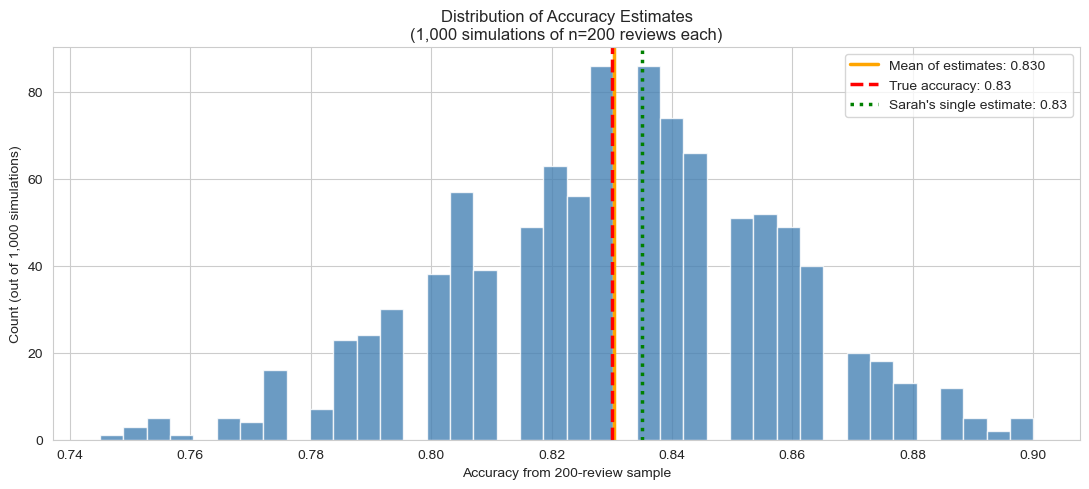

Spread of estimates (standard deviation): 0.0273
Min: 0.745  |  Max: 0.900
95% of estimates fall between: 0.775 and 0.880


In [5]:
# Repeat the 200-review sampling 1,000 times
N_SIMULATIONS = 1000

accuracy_estimates = []
for _ in range(N_SIMULATIONS):
    sample = np.random.binomial(n=1, p=TRUE_ACCURACY, size=SAMPLE_SIZE)
    accuracy_estimates.append(sample.mean())

accuracy_estimates = np.array(accuracy_estimates)

# Plot the distribution of estimates
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(accuracy_estimates, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(accuracy_estimates.mean(), color='orange', linewidth=2.5,
           label=f"Mean of estimates: {accuracy_estimates.mean():.3f}")
ax.axvline(TRUE_ACCURACY, color='red', linewidth=2.5, linestyle='--',
           label=f"True accuracy: {TRUE_ACCURACY:.2f}")
ax.axvline(sample_accuracy, color='green', linewidth=2.5, linestyle=':',
           label=f"Sarah's single estimate: {sample_accuracy:.2f}")
ax.set_xlabel("Accuracy from 200-review sample")
ax.set_ylabel("Count (out of 1,000 simulations)")
ax.set_title(f"Distribution of Accuracy Estimates\n({N_SIMULATIONS:,} simulations of n={SAMPLE_SIZE} reviews each)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Spread of estimates (standard deviation): {accuracy_estimates.std():.4f}")
print(f"Min: {accuracy_estimates.min():.3f}  |  Max: {accuracy_estimates.max():.3f}")
print(f"95% of estimates fall between: {np.percentile(accuracy_estimates, 2.5):.3f} and {np.percentile(accuracy_estimates, 97.5):.3f}")


### 💡 What do you notice?

- **The distribution is approximately normal (bell-shaped)** — even though the underlying data is binary (correct/incorrect), the distribution of *sample averages* from 1,000 simulations looks like a bell curve. This is the Central Limit Theorem in action.
- **The spread is real** — Sarah's single sample of 200 could easily give a result anywhere between about 77.5% and 88%, just by random chance. That's a 10-point range. Her "84%" is a point estimate, not a fact.
- **The centre is close to the truth** — across 1,000 simulations, the average estimate hovers very close to the true accuracy of 83%. With large samples, the estimates are *unbiased* — they're wrong on any individual trial, but right on average.

**Back to our scenario:**
> Priya asked "Is the model *exactly* 84% accurate?" The answer is: "No. 84% is our best estimate from 200 reviews. Based on how much estimates like this vary, the true accuracy is most likely between 78% and 89%. That's what a confidence interval tells us."

## 🎯 Confidence Intervals

**The idea in plain English:**
> A confidence interval is a range that probably contains the true value. A 95% CI says: if you repeated this experiment many times and computed the CI each time, 95% of those intervals would contain the true value.

**The election poll analogy:** A poll says "Party A leads with 43%, ± 3 percentage points, 95% confidence." The pollster is saying: if we ran this poll 100 times, roughly 95 of those polls would produce an interval that contains the true support for Party A. This particular poll's interval might or might not — but probably does.

**The formula for a proportion (like accuracy):**
```
Lower = p̂  −  1.96 × sqrt( p̂(1 − p̂) / n )
Upper = p̂  +  1.96 × sqrt( p̂(1 − p̂) / n )
```
where p̂ is the sample proportion, n is the sample size, and 1.96 is the Z-score for 95% confidence.

In [6]:
# Compute the 95% confidence interval for Sarah's accuracy
p_hat = sample_accuracy   # 0.84 (or whatever her sample gave)
n     = SAMPLE_SIZE       # 200

# Standard error of the proportion
se = np.sqrt(p_hat * (1 - p_hat) / n)

# Z-score for 95% confidence: 1.96
z_95 = 1.96
margin_of_error = z_95 * se

ci_lower = p_hat - margin_of_error
ci_upper = p_hat + margin_of_error

print(f"Sarah's sample accuracy (p̂):    {p_hat:.2%}")
print(f"Sample size (n):                {n}")
print(f"Standard error (SE):            {se:.4f}")
print(f"Margin of error (1.96 × SE):    {margin_of_error:.4f}  ({margin_of_error:.1%})")
print()
print(f"95% Confidence Interval:        [{ci_lower:.2%}, {ci_upper:.2%}]")
print()
print("Sarah can now write in her report:")
print(f"  '84% accuracy (95% CI: {ci_lower:.0%}–{ci_upper:.0%})'")
print()
print("Compare to the true accuracy we set:", TRUE_ACCURACY)
print(f"Is the true accuracy inside the interval? {ci_lower <= TRUE_ACCURACY <= ci_upper}")


Sarah's sample accuracy (p̂):    83.50%
Sample size (n):                200
Standard error (SE):            0.0262
Margin of error (1.96 × SE):    0.0514  (5.1%)

95% Confidence Interval:        [78.36%, 88.64%]

Sarah can now write in her report:
  '84% accuracy (95% CI: 78%–89%)'

Compare to the true accuracy we set: 0.83
Is the true accuracy inside the interval? True


## ✅ Section Summary

| Concept | What it means | Real-world use |
|---|---|---|
| **Sampling** | Measuring a smaller group to estimate the whole | Model evaluation on a test set is a sampling problem |
| **Standard Error** | How much sample means vary across different samples | Larger n → smaller SE → more certain estimate |
| **Confidence Interval** | A range that captures the true value approximately 95% of the time | "84% accuracy (95% CI: 78%–89%)" — the honest way to report model performance |
| **The Mis-reading** | 95% CI ≠ "95% probability the truth is in this range" | The CI is a property of the method, not this specific interval |

**Key insight for our scenario:**
> Sarah can now write in her report: "Model accuracy: 84% (95% CI: 78%–89%)." That single addition transforms a number Priya can't evaluate into one she can.

---
**Up next → Part 3:** Thursday — Aisha proposes the apology coupon, and Marcus asks whether it will actually reduce churn.
Open `04_ab_testing.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

This optional section covers:
- **Central Limit Theorem** — the theoretical foundation for why confidence intervals work on any kind of data
- **The CI mis-reading** — the most common error in interpreting a 95% CI (worth reading before you ever quote a CI to a stakeholder)
- **Visual CI on the simulation** — see your interval overlaid on the 1,000 simulated estimates
- **Sample size effect** — how doubling or quadrupling n shrinks the interval

## 🎯 The Central Limit Theorem

**The idea in plain English:**
> Even if the underlying data is not normally distributed, the *average* of many samples from that data will follow a normal distribution. The larger each sample, the tighter the normal distribution becomes.

**The Skittles analogy:** A jar of Skittles has wildly unequal colour proportions — not normal at all. Grab a handful of 30 Skittles, count the red ones, put them back, repeat 1,000 times. The distribution of your red-count per handful will look like a bell curve — even though the jar itself isn't normally distributed. That's the CLT.

**Why it matters for ML:** The CLT is why confidence intervals and hypothesis tests work on almost any data — as long as samples are large enough (n ≥ 30 is the standard rule of thumb). You don't need the raw data to be normal; you just need samples to be large enough.

Let's see the CLT in action with a non-normal source.


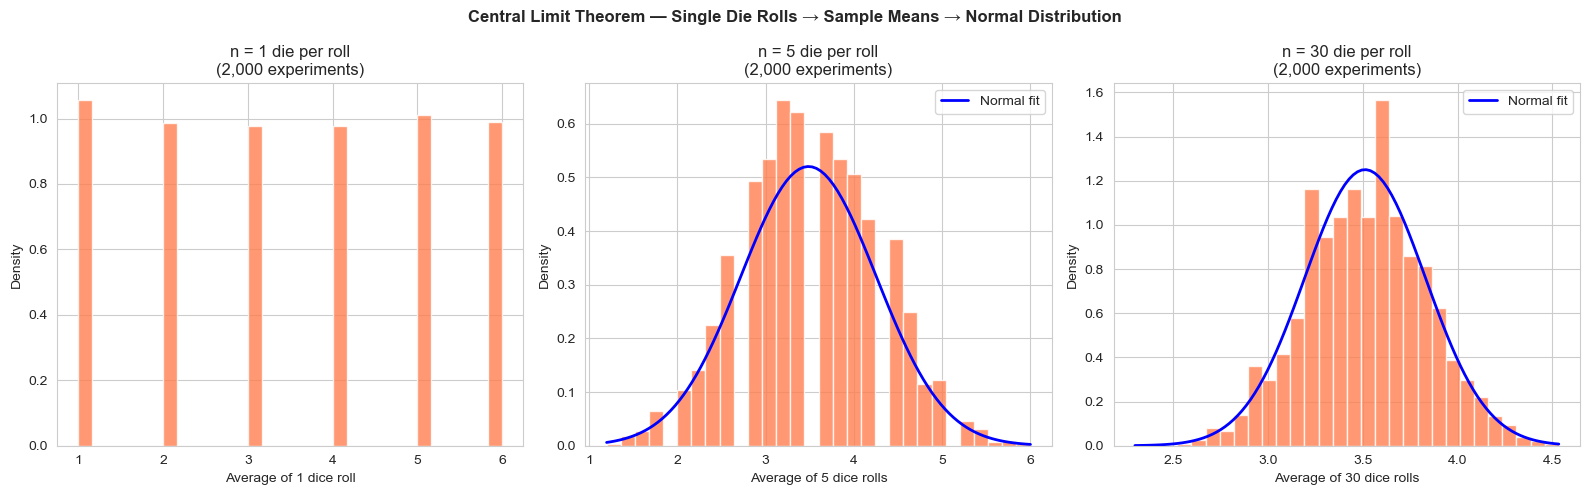

A single die roll is UNIFORM — each value (1–6) is equally likely. Not normal at all.
Average of 5 dice: starting to look bell-shaped.
Average of 30 dice: very close to normal. That's the CLT.


In [7]:
# CLT demonstration: dice rolls (clearly non-normal source)
np.random.seed(42)

n_experiments = 2000

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, sample_size in enumerate([1, 5, 30]):
    # Roll 'sample_size' dice 2000 times, record the average each time
    rolls = np.random.randint(1, 7, size=(n_experiments, sample_size))
    means = rolls.mean(axis=1)

    ax = axes[i]
    ax.hist(means, bins=30, color='coral', edgecolor='white', alpha=0.8, density=True)
    ax.set_xlabel(f"Average of {sample_size} dice roll{'s' if sample_size > 1 else ''}")
    ax.set_ylabel("Density")
    ax.set_title(f"n = {sample_size} die per roll\n({n_experiments:,} experiments)")

    # Add normal curve for reference (when n=30)
    if sample_size >= 5:
        x = np.linspace(means.min(), means.max(), 100)
        normal_curve = st.norm.pdf(x, means.mean(), means.std())
        ax.plot(x, normal_curve, 'b-', linewidth=2, label='Normal fit')
        ax.legend()

plt.suptitle("Central Limit Theorem — Single Die Rolls → Sample Means → Normal Distribution",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("A single die roll is UNIFORM — each value (1–6) is equally likely. Not normal at all.")
print("Average of 5 dice: starting to look bell-shaped.")
print("Average of 30 dice: very close to normal. That's the CLT.")


### 💡 What do you notice?

- **Single die roll (n=1):** completely flat — every value equally likely. Nothing like a bell curve.
- **Average of 5 dice (n=5):** already starting to hump in the middle. The CLT is kicking in.
- **Average of 30 dice (n=30):** closely matches the normal distribution (blue line). The source data is still uniformly distributed — only the *averages* are normal.

**This is why Sarah can use confidence intervals on her accuracy estimate**, even though the underlying data is binary (correct/incorrect, not normally distributed). The 200-review sample mean follows an approximately normal distribution — the CLT guarantees it.


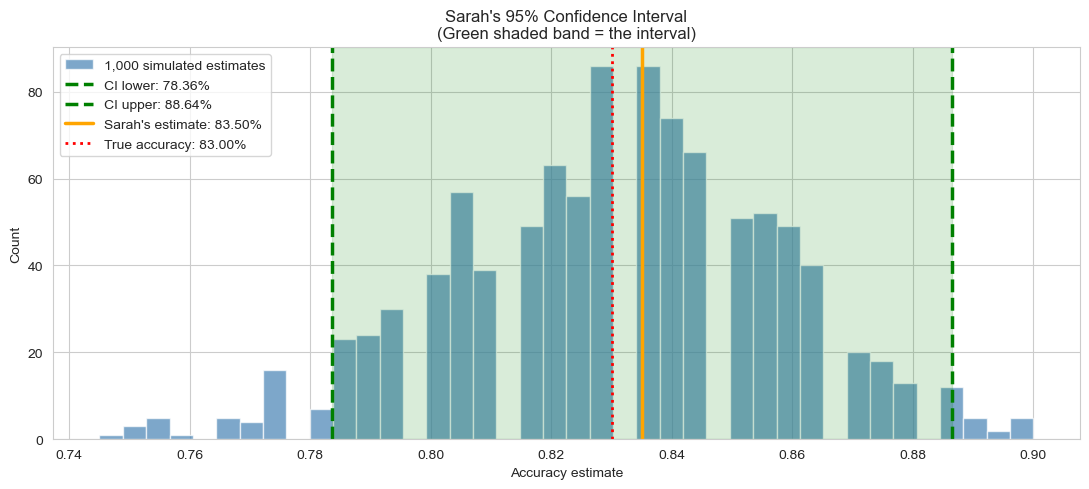

Of the 1,000 simulated estimates, 94.6% fell inside Sarah's confidence interval.
(We'd expect about 95% — this is what '95% confidence' means in practice.)


In [8]:
# Visual: the confidence interval on the distribution of estimates
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(accuracy_estimates, bins=40, color='steelblue', edgecolor='white', alpha=0.7, label='1,000 simulated estimates')

# Shade the CI region
x_fill = np.linspace(ci_lower, ci_upper, 100)
ax.axvline(ci_lower, color='green', linewidth=2.5, linestyle='--', label=f'CI lower: {ci_lower:.2%}')
ax.axvline(ci_upper, color='green', linewidth=2.5, linestyle='--', label=f'CI upper: {ci_upper:.2%}')
ax.axvline(p_hat, color='orange', linewidth=2.5, label=f"Sarah's estimate: {p_hat:.2%}")
ax.axvline(TRUE_ACCURACY, color='red', linewidth=2, linestyle=':', label=f'True accuracy: {TRUE_ACCURACY:.2%}')
ax.axvspan(ci_lower, ci_upper, alpha=0.15, color='green')

ax.set_xlabel("Accuracy estimate")
ax.set_ylabel("Count")
ax.set_title("Sarah's 95% Confidence Interval\n(Green shaded band = the interval)")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# What fraction of the 1000 simulations fell inside the CI?
inside_ci = ((accuracy_estimates >= ci_lower) & (accuracy_estimates <= ci_upper)).mean()
print(f"Of the 1,000 simulated estimates, {inside_ci:.1%} fell inside Sarah's confidence interval.")
print("(We'd expect about 95% — this is what '95% confidence' means in practice.)")


### 💡 What do you notice?

- **The true accuracy (red dotted line) is inside Sarah's CI** — the interval did its job this time. With 95% CIs, we'd expect to capture the truth about 95 times out of 100.
- **The CI is neither tiny nor huge** — roughly ±6 percentage points from 84%. That's the price of using only 200 reviews. With 1,000 reviews, the margin would shrink to about ±3%.
- **The green band covers the bulk of the simulation distribution** — again confirming that the CI captures roughly the right range.

**The most common mis-reading to avoid:**
❌ "There is a 95% probability that the true accuracy is between 78% and 89%."
✅ "If we repeated this labelling exercise many times, 95% of the confidence intervals we'd compute would contain the true accuracy."

The true accuracy is a fixed number — it doesn't have a probability of being in a range. What has the 95% property is the *method*, not this particular interval.


In [9]:
# Bonus: show what happens when sample size increases
print("How sample size affects the confidence interval width:")
print()
print(f"{'n':>8} | {'95% CI':>20} | {'Width':>8}")
print("-" * 45)

for n_test in [50, 100, 200, 500, 1000, 5000]:
    se_test = np.sqrt(p_hat * (1 - p_hat) / n_test)
    lower   = p_hat - 1.96 * se_test
    upper   = p_hat + 1.96 * se_test
    width   = upper - lower
    print(f"  {n_test:>6} | [{lower:.1%} – {upper:.1%}] | {width:.1%}")

print()
print("To halve the interval width, you need to QUADRUPLE the sample size.")
print("This is the 'square root rule' — one of the most important practical tradeoffs in ML evaluation.")


How sample size affects the confidence interval width:

       n |               95% CI |    Width
---------------------------------------------
      50 | [73.2% – 93.8%] | 20.6%
     100 | [76.2% – 90.8%] | 14.6%
     200 | [78.4% – 88.6%] | 10.3%
     500 | [80.2% – 86.8%] | 6.5%
    1000 | [81.2% – 85.8%] | 4.6%
    5000 | [82.5% – 84.5%] | 2.1%

To halve the interval width, you need to QUADRUPLE the sample size.
This is the 'square root rule' — one of the most important practical tradeoffs in ML evaluation.
